In [1]:
import sys
sys.path.append("..")
from src.pose_extractor import extract_keypoints_from_video
from src.geometry import knee_angle, torso_lean, detect_contact_frame

video_path = "../data/raw_clips/header/header_02.mp4"
keypoints = extract_keypoints_from_video(video_path)
knee_angles = [knee_angle(kp) for kp in keypoints]
torso_angles = [torso_lean(kp) for kp in keypoints]
contact = detect_contact_frame(keypoints, shot_type="header")

2026-07-18 23:39:57,389 - INFO - Extracted keypoints for 50 frames from ../data/raw_clips/header/header_02.mp4


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = ["#0f4c3a", "#1a7a5e", "#2fa084", "#5cbfa3", "#8ad4bf", "#b8e6d8"]
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.edgecolor"] = "#cccccc"

dual-axis styled biomechanics chart

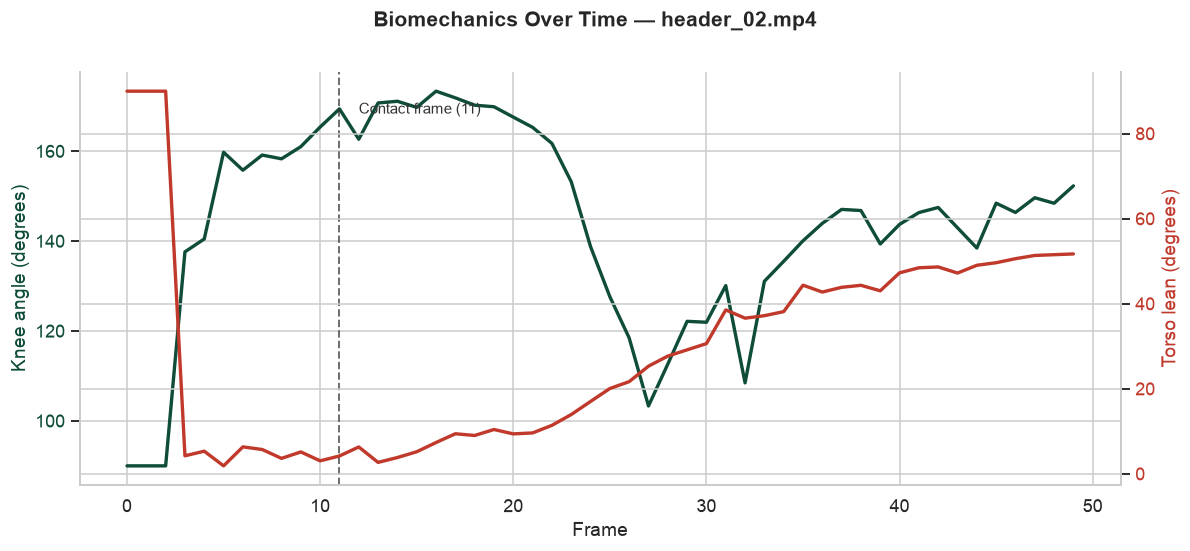

In [3]:
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(knee_angles, color=PALETTE[0], linewidth=2.2, label="Knee angle (°)")
ax1.set_xlabel("Frame")
ax1.set_ylabel("Knee angle (degrees)", color=PALETTE[0])
ax1.tick_params(axis="y", labelcolor=PALETTE[0])
ax1.spines[["top"]].set_visible(False)

ax2 = ax1.twinx()
ax2.plot(torso_angles, color="#c0392b", linewidth=2.2, linestyle="-", label="Torso lean (°)")
ax2.set_ylabel("Torso lean (degrees)", color="#c0392b")
ax2.tick_params(axis="y", labelcolor="#c0392b")
ax2.spines[["top"]].set_visible(False)

ax1.axvline(contact, color="#333", linestyle="--", linewidth=1.3, alpha=0.7)
ax1.text(contact + 1, max(knee_angles) - 5, f"Contact frame ({contact})", fontsize=9.5, color="#333")

fig.suptitle("Biomechanics Over Time — header_02.mp4", fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
plt.show()

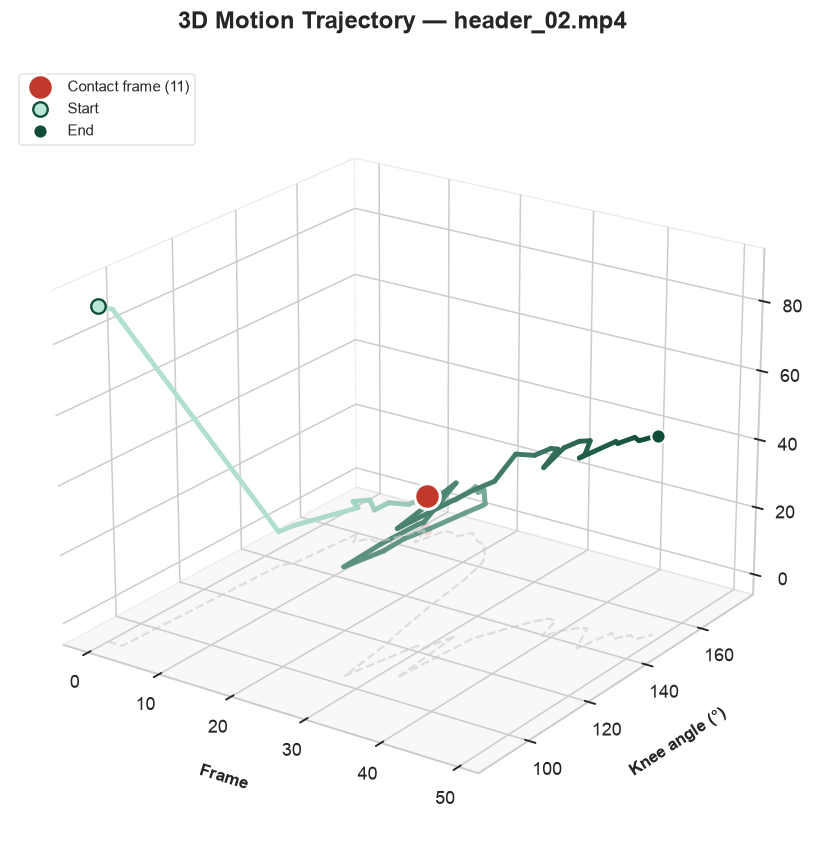

In [4]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors
import numpy as np

frames_arr = np.array(range(len(knee_angles)))
knee_arr = np.array(knee_angles)
torso_arr = np.array(torso_angles)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Gradient-colored trajectory: segment-by-segment coloring from start (light) to end (dark)
cmap = mcolors.LinearSegmentedColormap.from_list("traj", ["#b8e6d8", "#0f4c3a"])
n_segments = len(frames_arr) - 1
for i in range(n_segments):
    ax.plot(frames_arr[i:i+2], knee_arr[i:i+2], torso_arr[i:i+2],
             color=cmap(i / n_segments), linewidth=3.2, solid_capstyle="round")

# Floor projection shadow (drop the trajectory onto the bottom plane for depth cue)
floor_z = min(torso_arr) - 8
ax.plot(frames_arr, knee_arr, [floor_z]*len(frames_arr), color="#cccccc", linewidth=1.5, alpha=0.6, linestyle="--")

# Contact point — bigger, glowing marker
ax.scatter([contact], [knee_angles[contact]], [torso_angles[contact]],
           color="#c0392b", s=280, edgecolor="white", linewidth=2, zorder=10,
           label=f"Contact frame ({contact})")
ax.scatter([contact], [knee_angles[contact]], [floor_z],
           color="#c0392b", s=60, alpha=0.4, edgecolor="none")

# Start/end markers
ax.scatter([frames_arr[0]], [knee_arr[0]], [torso_arr[0]], color="#b8e6d8", s=90, edgecolor="#0f4c3a", linewidth=1.5, zorder=9, label="Start")
ax.scatter([frames_arr[-1]], [knee_arr[-1]], [torso_arr[-1]], color="#0f4c3a", s=90, edgecolor="white", linewidth=1.5, zorder=9, label="End")

ax.set_xlabel("Frame", labelpad=14, fontsize=11, fontweight="bold")
ax.set_ylabel("Knee angle (°)", labelpad=14, fontsize=11, fontweight="bold")
ax.set_zlabel("Torso lean (°)", labelpad=14, fontsize=11, fontweight="bold")
ax.set_title("3D Motion Trajectory — header_02.mp4", fontsize=16, fontweight="bold", pad=25)

ax.set_zlim(floor_z, max(torso_arr) + 5)
ax.xaxis.pane.set_facecolor((1, 1, 1, 0.9))
ax.yaxis.pane.set_facecolor((1, 1, 1, 0.9))
ax.zaxis.pane.set_facecolor((0.95, 0.95, 0.95, 0.5))
ax.xaxis.pane.set_edgecolor("#dddddd")
ax.yaxis.pane.set_edgecolor("#dddddd")
ax.zaxis.pane.set_edgecolor("#dddddd")
ax.grid(alpha=0.15)

ax.legend(frameon=True, facecolor="white", edgecolor="#dddddd", loc="upper left", fontsize=10)
ax.view_init(elev=22, azim=-55)

plt.tight_layout()
plt.show()